# Нафикова Лиана

In [ ]:
!pip install openml optuna

In [ ]:
from tqdm import tqdm

import openml

import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np

import optuna

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

Чтобы минимизировать время обработки датасетов, ограничим число классов, признаков, строк

In [ ]:
n_datasets = 300
offset = 0

In [ ]:
all_datasets = []
while len(all_datasets) < n_datasets:
        datasets_batch = openml.datasets.list_datasets(
            output_format='dataframe',
            offset=offset,
            limit=128,
            status='active')

        valid_datasets = []
        for _, dataset in datasets_batch.iterrows():
              required_columns = ['NumberOfFeatures', 'NumberOfInstances', 'NumberOfClasses', 'NumberOfMissingValues']
              if not all(col in dataset.index for col in required_columns):
                  continue

              features_ok = 5 <= dataset['NumberOfFeatures'] <= 100
              instances_ok = 500 <= dataset['NumberOfInstances'] <= 2000
              classes_ok = 3 <= dataset['NumberOfClasses'] <= 10
              missing_ok = dataset['NumberOfMissingValues'] == 0

              task_type_ok = True
              if 'task_type' in dataset.index:
                  task_type_ok = dataset['task_type'] == 'Supervised Classification'
              if features_ok and instances_ok and classes_ok and missing_ok and task_type_ok:
                  valid_datasets.append(dataset)

        all_datasets.extend(valid_datasets)
        offset += 128

In [ ]:
len(all_datasets)

367

In [ ]:
df_datasets = pd.DataFrame(all_datasets)
df_datasets.head(20)

,did,name,version,uploader,status,format,MajorityClassSize,MaxNominalAttDistinctValues,MinorityClassSize,NumberOfClasses,NumberOfFeatures,NumberOfInstances,NumberOfInstancesWithMissingValues,NumberOfMissingValues,NumberOfNumericFeatures,NumberOfSymbolicFeatures
11,11,balance-scale,1,1,active,ARFF,288.0,3.0,49.0,3.0,5.0,625.0,0.0,0.0,4.0,1.0
14,14,mfeat-fourier,1,1,active,ARFF,200.0,10.0,200.0,10.0,77.0,2000.0,0.0,0.0,76.0,1.0
16,16,mfeat-karhunen,1,1,active,ARFF,200.0,10.0,200.0,10.0,65.0,2000.0,0.0,0.0,64.0,1.0
18,18,mfeat-morphological,1,1,active,ARFF,200.0,10.0,200.0,10.0,7.0,2000.0,0.0,0.0,6.0,1.0
22,22,mfeat-zernike,1,1,active,ARFF,200.0,10.0,200.0,10.0,48.0,2000.0,0.0,0.0,47.0,1.0
23,23,cmc,1,1,active,ARFF,629.0,4.0,333.0,3.0,10.0,1473.0,0.0,0.0,2.0,8.0
54,54,vehicle,1,1,active,ARFF,218.0,4.0,199.0,4.0,19.0,846.0,0.0,0.0,18.0,1.0
181,181,yeast,1,1,active,ARFF,463.0,10.0,5.0,10.0,9.0,1484.0,0.0,0.0,8.0,1.0
377,377,synthetic_control,1,2,active,ARFF,100.0,6.0,100.0,6.0,61.0,600.0,0.0,0.0,60.0,1.0
458,458,analcatdata_authorship,1,2,active,ARFF,317.0,4.0,55.0,4.0,71.0,841.0,0.0,0.0,70.0,1.0


Рассмотрим

In [ ]:
dataset = openml.datasets.get_dataset(40691)
dataset

OpenML Dataset
Name.........: wine-quality-red
Version......: 1
Format.......: ARFF
Upload Date..: 2017-04-06 12:14:58
Licence......: public
Download URL.: https://api.openml.org/data/v1/download/4965268/wine-quality-red.arff
OpenML URL...: https://www.openml.org/d/40691
# of features: None

In [ ]:
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [ ]:
y.unique()

['5', '6', '7', '4', '8', '3']
Categories (6, object): ['3' < '4' < '5' < '6' < '7' < '8']

In [ ]:
n_features = X.shape[1]
n_samples = X.shape[0]
n_classes = len(np.unique(y))
n_features, n_samples, n_classes

(11, 1599, 6)

In [ ]:
numerical_features = X.select_dtypes(include=[np.number])

In [ ]:
min_values = numerical_features.min()
mean_of_min = min_values.mean()
print(f"Среднее минимальных значений: {mean_of_min}")

max_values = numerical_features.max()
mean_of_max = max_values.mean()
print(f"Среднее максимальных значений: {mean_of_max}")

mean_values = numerical_features.mean()
mean_of_means = mean_values.mean()
print(f"Среднее средних значений: {mean_of_means}")

std_values = numerical_features.std()
mean_of_stds = std_values.mean()
print(f"Среднее стандартных отклонений: {mean_of_stds}")

skew_values = numerical_features.apply(stats.skew)
mean_skewness = skew_values.mean()
print(f"Средняя асимметрия: {mean_skewness}")

kurtosis_values = numerical_features.apply(stats.kurtosis)
mean_kurtosis = kurtosis_values.mean()
print(f"Средний эксцесс: {mean_kurtosis}")

Среднее минимальных значений: 2.2810972727272727
Среднее максимальных значений: 37.95497181818182
Среднее средних значений: 8.134219224515322
Среднее стандартных отклонений: 4.392625484509787
Средняя асимметрия: 1.6815346984881843
Средний эксцесс: 8.279087779260573


In [ ]:
y_encoded = LabelEncoder().fit_transform(y)

In [ ]:
n_estimators_list = [50, 70, 100]
max_depth_list = [4, 6, 8]

In [ ]:
best_score = 0
best_params = {}

In [ ]:
for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
          model = RandomForestClassifier(
              n_estimators=n_estimators,
              max_depth=max_depth,
              random_state=32
          )
          scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')
          mean_score = np.mean(scores)

          if mean_score > best_score:
              best_score = mean_score
              best_params = {
                  'n_estimators': n_estimators,
                  'max_depth': max_depth
              }

In [ ]:
best_params

{'n_estimators': 70, 'max_depth': 8}

In [ ]:
best_score

np.float64(0.6723158307210031)

In [ ]:
dataset_df = X.copy()
dataset_df['target'] = y

In [ ]:
dataset_shuffled = dataset_df.sample(frac=1, random_state=52).reset_index(drop=True)
dataset_shuffled = dataset_shuffled.sample(frac=1, axis=1, random_state=52)

X_shuffled = dataset_shuffled.drop(columns=['target'], axis = 1)
y_shuffled = dataset_shuffled['target']
y_shuffled_encoded = y_shuffled.copy()
y_shuffled_encoded = LabelEncoder().fit_transform(y_shuffled_encoded)

In [ ]:
numerical_features = X_shuffled.select_dtypes(include=[np.number])

In [ ]:
min_values = numerical_features.min()
mean_of_min = min_values.mean()
print(f"Среднее минимальных значений: {mean_of_min}")

max_values = numerical_features.max()
mean_of_max = max_values.mean()
print(f"Среднее максимальных значений: {mean_of_max}")

mean_values = numerical_features.mean()
mean_of_means = mean_values.mean()
print(f"Среднее средних значений: {mean_of_means}")

std_values = numerical_features.std()
mean_of_stds = std_values.mean()
print(f"Среднее стандартных отклонений: {mean_of_stds}")

skew_values = numerical_features.apply(stats.skew)
mean_skewness = skew_values.mean()
print(f"Средняя асимметрия: {mean_skewness}")

kurtosis_values = numerical_features.apply(stats.kurtosis)
mean_kurtosis = kurtosis_values.mean()
print(f"Средний эксцесс: {mean_kurtosis}")

Среднее минимальных значений: 2.2810972727272727
Среднее максимальных значений: 37.95497181818182
Среднее средних значений: 8.134219224515322
Среднее стандартных отклонений: 4.392625484509791
Средняя асимметрия: 1.6815346984881998
Средний эксцесс: 8.279087779260575


In [ ]:
best_score = 0
best_params = {}

In [ ]:
for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
          model = RandomForestClassifier(
              n_estimators=n_estimators,
              max_depth=max_depth,
              random_state=32
          )
          scores = cross_val_score(model, X_shuffled, y_shuffled, cv=5, scoring='accuracy')
          mean_score = np.mean(scores)

          if mean_score > best_score:
              best_score = mean_score
              best_params = {
                  'n_estimators': n_estimators,
                  'max_depth': max_depth
              }

In [ ]:
best_params

{'n_estimators': 70, 'max_depth': 8}

In [ ]:
best_score

np.float64(0.6723158307210031)

Заметим, что данные не поменялись после перемешивания.



In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

def optimize_extra_trees(trial, X, y):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10)
    }
    model = ExtraTreesClassifier(**params, random_state=52, n_jobs=-1)
    scores = cross_val_score(model, X, y, cv=2, scoring='accuracy', n_jobs=-1)
    return scores.mean()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

def optimize_gradient_boosting(trial, X, y):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10)
    }
    model = GradientBoostingClassifier(**params, random_state=52)
    scores = cross_val_score(model, X, y, cv=2, scoring='accuracy', n_jobs=-1)
    return scores.mean()

In [ ]:
def optimize_random_forest(trial, X, y):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10)
    }
    model = RandomForestClassifier(**params, random_state=52, n_jobs=-1)
    scores = cross_val_score(model, X, y, cv=2, scoring='accuracy', n_jobs=-1)
    return scores.mean()

In [ ]:
def evaluate_algorithm(X, y, algorithm_id):
    X_numeric = X.select_dtypes(include=[np.number])
    if X_numeric.shape[1] == 0:
        return 0.0, {}

    le_y = LabelEncoder()
    y_encoded = le_y.fit_transform(y)

    optimizers = {
        0: optimize_random_forest,
        1: optimize_extra_trees,
        2: optimize_gradient_boosting
    }

    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: optimizers[algorithm_id](trial, X_numeric, y_encoded),
                   n_trials=2, n_jobs=-1)

    return study.best_value, study.best_params

In [ ]:
def calculate_meta_features(X, y):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    n_features = X.shape[1]
    n_samples = X.shape[0]
    n_classes = len(np.unique(y_encoded))
    samples_features_ratio = n_samples / n_features if n_features > 0 else 0

    numerical_features = X.select_dtypes(include=[np.number])
    numerical_count = len(numerical_features.columns)
    categorical_count = n_features - numerical_count

    stats_values = [0] * 6  # meta_min, meta_max, meta_mean, meta_std, meta_skew, meta_kurtosis
    if numerical_count > 0:
        stats_functions = ['min', 'max', 'mean', 'std', lambda x: stats.skew(x), lambda x: stats.kurtosis(x)]
        stats_values = [numerical_features.apply(func).mean() for func in stats_functions]

    return [n_features, n_samples, n_classes, samples_features_ratio,
            *stats_values, categorical_count, numerical_count]

In [ ]:
def process_single_dataset(dataset_info):
    try:
        dataset_id = dataset_info['did']
        dataset = openml.datasets.get_dataset(dataset_id)

        if dataset.default_target_attribute is None:
            return [], -1, 0, 0, 0, "Skipped: No target"

        X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)

        meta_features = calculate_meta_features(X, y)

        algorithms_scores = []
        rf_params = {}
        for algo_id in range(3):
            score, params = evaluate_algorithm(X, y, algo_id)
            if algo_id == 0:
                rf_params = params
            algorithms_scores.append(score)

        valid_scores = [s for s in algorithms_scores if s > 0]
        if not valid_scores:
            return [], -1, 0, 0, 0, "Skipped: No valid scores"

        best_algorithm = np.argmax(algorithms_scores)

        n_estimators = rf_params.get('n_estimators', 100)
        max_depth = rf_params.get('max_depth', 10)
        min_samples_split = rf_params.get('min_samples_split', 2)

        return meta_features, best_algorithm, n_estimators, max_depth, min_samples_split, "Success"

    except Exception as e:
        return [], -1, 0, 0, 0, f"Error: {str(e)}"

In [ ]:
def build_large_meta_dataset(all_datasets_info, batch_size=64):
    meta_features_list = []
    targets = []
    params_list = []
    results_log = []

    successful_count = skipped_count = error_count = 0

    for i in tqdm(range(0, len(all_datasets_info), batch_size)):
        batch = all_datasets_info[i:i + batch_size]

        for j, dataset_info in enumerate(batch):
            meta_features, best_algo, n_est, max_d, min_split, status = process_single_dataset(dataset_info)

            if status == "Success" and best_algo != -1 and len(meta_features) > 0:
                meta_features_list.append(meta_features)
                targets.append(best_algo)
                params_list.append([n_est, max_d, min_split])
                successful_count += 1
            elif "Skipped" in status:
                skipped_count += 1
            else:
                error_count += 1

    meta_columns = ['n_features', 'n_samples', 'n_classes', 'samples_features_ratio',
                   'meta_min', 'meta_max', 'meta_mean', 'meta_std', 'meta_skew',
                   'meta_kurtosis', 'categorical_count', 'numerical_count']

    meta_df = pd.DataFrame(meta_features_list, columns=meta_columns)
    meta_df['best_algorithm'] = targets
    meta_df[['n_estimators', 'max_depth', 'min_samples_split']] = params_list

    return meta_df

In [ ]:
all_datasets = df_datasets.to_dict('records')
large_meta_dataset = build_large_meta_dataset(all_datasets, batch_size=128)

  0%|          | 0/3 [00:00<?, ?it/s][I 2025-11-07 22:16:33,180] A new study created in memory with name: no-name-695e7d79-f4a1-4a82-95aa-bcb3682b982d
[I 2025-11-07 22:16:33,527] Trial 0 finished with value: 0.5056012943393136 and parameters: {'n_estimators': 48, 'max_depth': 6, 'min_samples_split': 8}. Best is trial 0 with value: 0.5056012943393136.
[I 2025-11-07 22:16:33,771] Trial 1 finished with value: 0.5232192594413041 and parameters: {'n_estimators': 40, 'max_depth': 3, 'min_samples_split': 3}. Best is trial 1 with value: 0.5232192594413041.
[I 2025-11-07 22:16:33,775] A new study created in memory with name: no-name-796be8ad-2c61-4d5e-b069-91f0d4ad4032
[I 2025-11-07 22:16:34,202] Trial 0 finished with value: 0.5024012861472925 and parameters: {'n_estimators': 83, 'max_depth': 7, 'min_samples_split': 8}. Best is trial 0 with value: 0.5024012861472925.
[I 2025-11-07 22:16:34,284] Trial 1 finished with value: 0.51354755468174 and parameters: {'n_estimators': 13, 'max_depth': 5, 'm

/tmp/ipython-input-3221601046.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=algorithm_labels, y=algo_counts.values, ax=axes[0,1], palette='viridis')


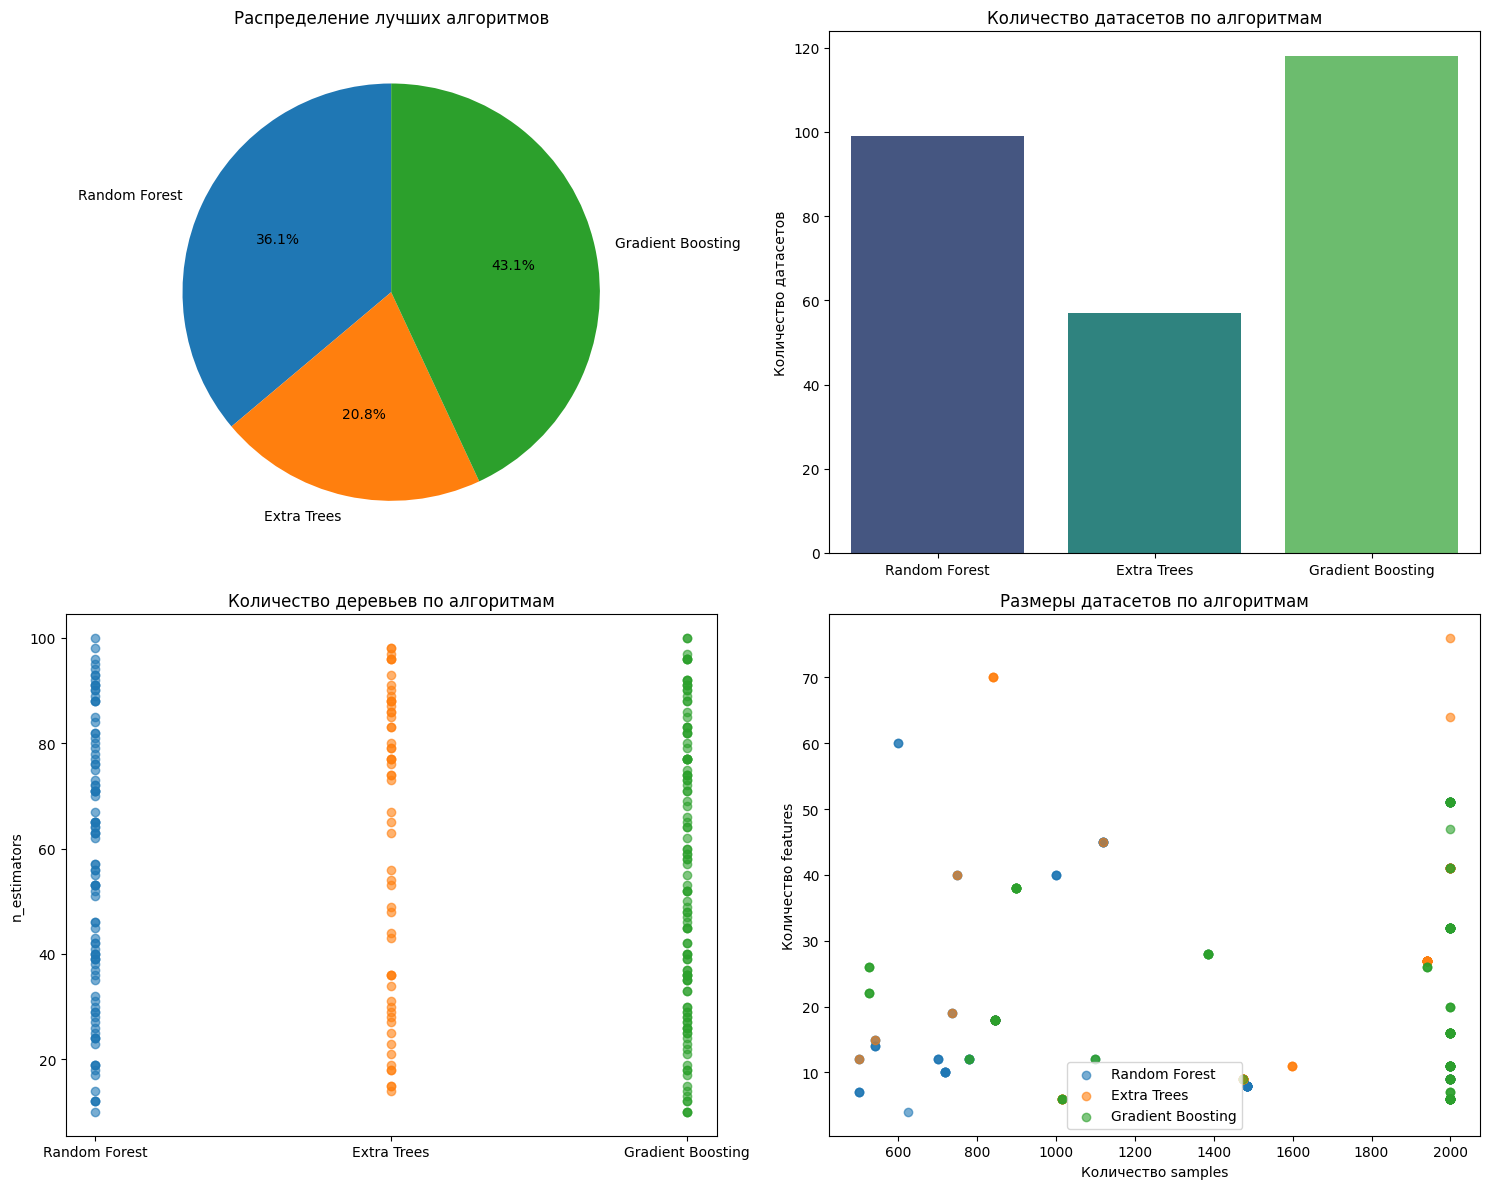

In [ ]:
algo_names = {0: 'Random Forest', 1: 'Extra Trees', 2: 'Gradient Boosting'}
algo_counts = large_meta_dataset['best_algorithm'].value_counts().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Круговая диаграмма
algorithm_labels = [algo_names[i] for i in algo_counts.index]
axes[0,0].pie(algo_counts.values, labels=algorithm_labels, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Распределение лучших алгоритмов')

# 2. Столбчатая диаграмма
sns.barplot(x=algorithm_labels, y=algo_counts.values, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Количество датасетов по алгоритмам')
axes[0,1].set_ylabel('Количество датасетов')

# 3. Распределение параметров Количества деревьев для каждого алгоритма
for i, algo_name in algo_names.items():
    algo_data = large_meta_dataset[large_meta_dataset['best_algorithm'] == i]
    axes[1,0].scatter([algo_name] * len(algo_data), algo_data['n_estimators'],
                     alpha=0.6, label=algo_name)
axes[1,0].set_title('Количество деревьев по алгоритмам')
axes[1,0].set_ylabel('n_estimators')

# 4. Соотношение размеров датасетов и лучших алгоритмов
for i, algo_name in algo_names.items():
    algo_data = large_meta_dataset[large_meta_dataset['best_algorithm'] == i]
    axes[1,1].scatter(algo_data['n_samples'], algo_data['n_features'],
                     alpha=0.6, label=algo_name)
axes[1,1].set_xlabel('Количество samples')
axes[1,1].set_ylabel('Количество features')
axes[1,1].set_title('Размеры датасетов по алгоритмам')
axes[1,1].legend()

plt.tight_layout()
plt.show()

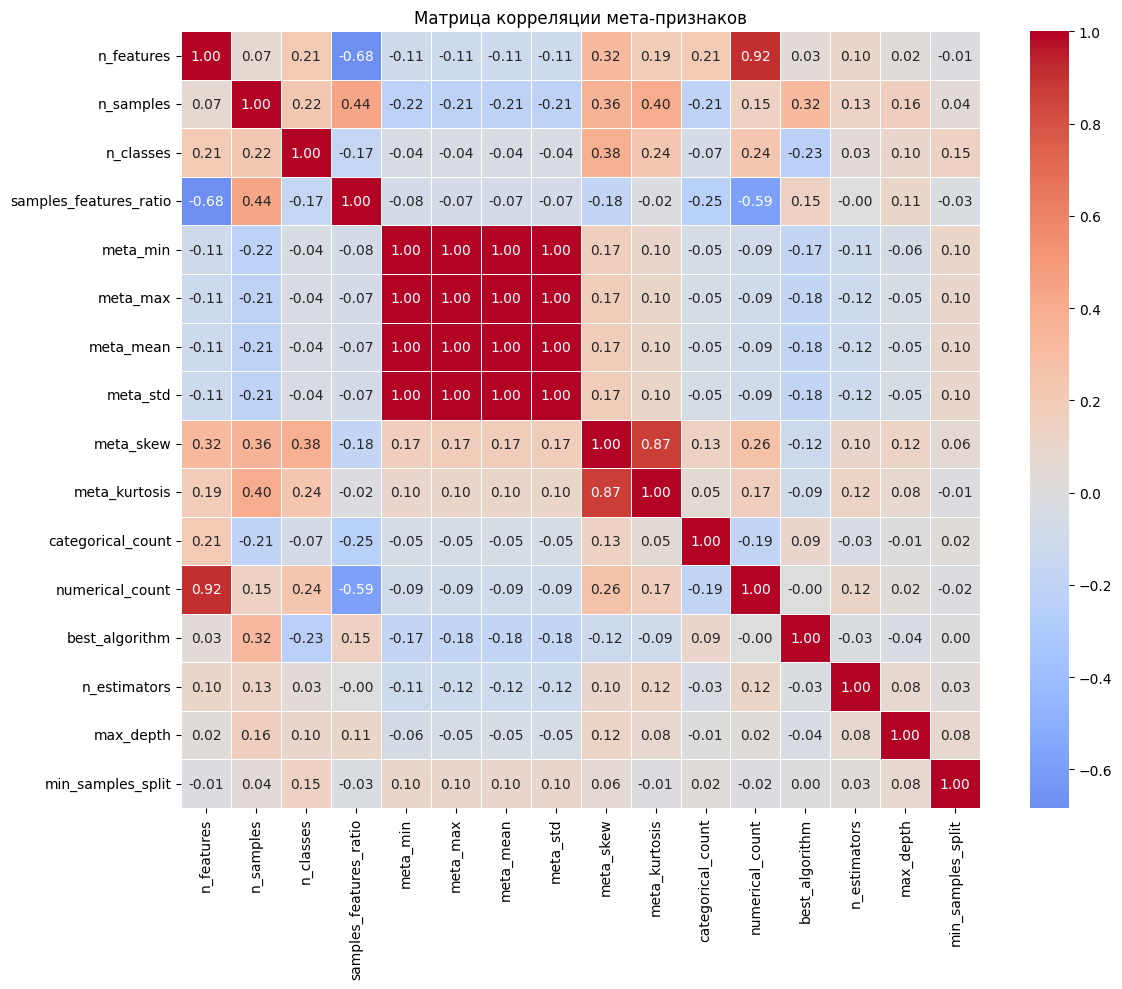

In [ ]:
correlation_matrix = large_meta_dataset.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции мета-признаков')
plt.tight_layout()
plt.show()

Взаимосвязь статистических показателей (meta_mean, meta_std, meta_max, meta_min): Была обнаружена тесная взаимосвязь между средним значением, разбросом и экстремальными значениями признаков в исходных наборах данных. Поскольку meta_mean (среднее значение) является центральной и наиболее информативной характеристикой, именно он был сохранен в мета-наборе. Остальные признаки этой группы (meta_std, meta_max, meta_min) были исключены как производные и избыточные.



In [ ]:
cleaned_meta_dataset = large_meta_dataset.drop(columns=['meta_std', 'meta_min', 'meta_max'])

In [ ]:
cleaned_meta_dataset.head()

,n_features,n_samples,n_classes,samples_features_ratio,meta_mean,meta_skew,meta_kurtosis,categorical_count,numerical_count,best_algorithm,n_estimators,max_depth,min_samples_split
0,4,625,3,156.250000,3.000000,0.000000,-1.300000,0,4,0,40,3,3
1,76,2000,10,26.315789,0.132032,0.544292,0.115710,0,76,1,88,6,6
2,64,2000,10,31.250000,0.053085,-0.004282,-0.048539,0,64,1,19,6,10
3,6,2000,10,333.333333,1052.699732,0.531168,-0.537896,0,6,0,40,7,5
4,47,2000,10,42.553191,88.636429,0.790237,0.730560,0,47,2,25,6,2


Теперь визуализируем мета-набор данных проекцией на двумерном графике. Для этого воспользуемся методом главных компонент:

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


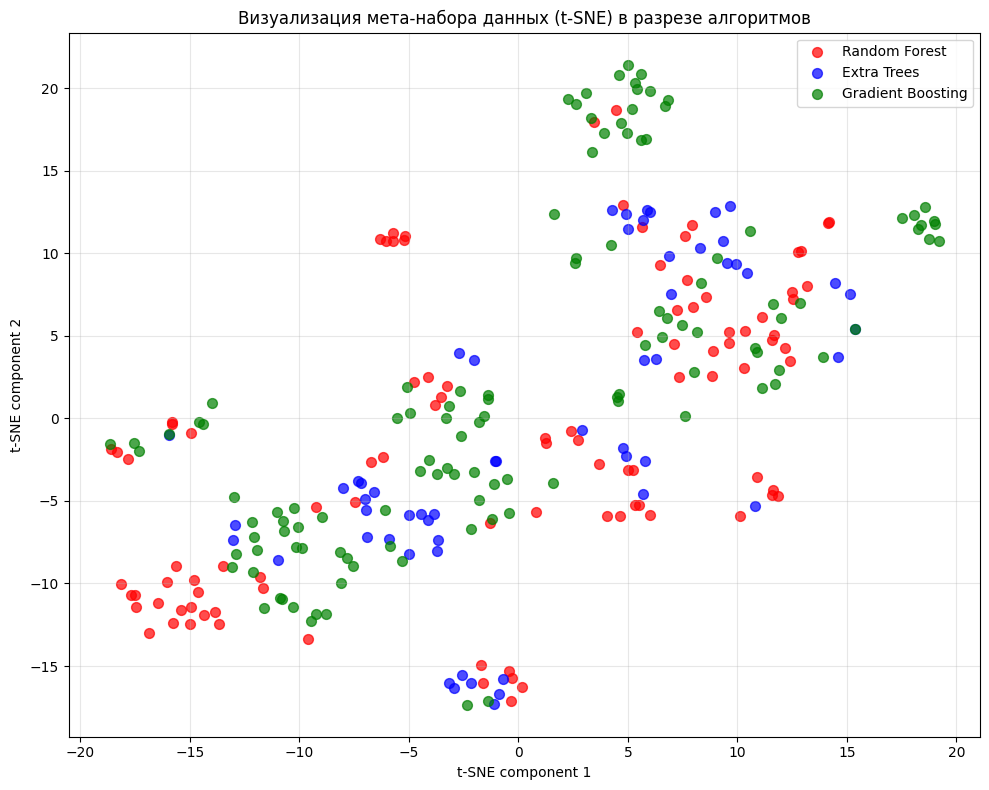

In [ ]:
from sklearn.manifold import TSNE

X_meta = cleaned_meta_dataset.drop(columns=['best_algorithm'])
y_meta = cleaned_meta_dataset['best_algorithm']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_meta)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
algo_names = {0: 'Random Forest', 1: 'Extra Trees', 2: 'Gradient Boosting'}
colors = ['red', 'blue', 'green']

for algo_id in sorted(y_meta.unique()):
    mask = y_meta == algo_id
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=colors[algo_id],
                label=algo_names[algo_id],
                alpha=0.7,
                s=50)

plt.title('Визуализация мета-набора данных (t-SNE) в разрезе алгоритмов')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Главное, что бросается в глаза - это то, что точки разных цветов (Random Forest, Extra Trees, Gradient Boosting) перемешаны, но при этом образуют отдельные кластеры в разных областях графика. Это говорит о том, что алгоритмы в некоторых случаях выдают схожие результаты (перекрывающиеся точки), а в других - значительно различаются (разделенные кластеры).
Можно заметить области графика, где преобладает определенный цвет. Например, есть скопление зеленых точек в верхнем правом углу, что указывает на то, что Gradient Boosting может иметь преимущество в этой области данных. Аналогично, в левой нижней части больше красных точек, что может говорить о лучшей производительности Random Forest там.

In [ ]:
X = X_meta
y = y_meta
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=52)

In [ ]:
X_train.shape

(219, 12)

In [ ]:
X_test.shape

(55, 12)

In [ ]:
dummy_model = DummyClassifier(strategy='stratified', random_state=52)
dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
print(f"Accuracy: {dummy_accuracy:.2f}")

Accuracy: 0.42


In [ ]:
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 100)
    max_depth = trial.suggest_int('max_depth', 3, 8)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=52,
        n_jobs=-1
    )
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1).mean()
    return score

print("Оптимизация Random Forest")
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=20)
print(study_rf.best_params)
print(f"Random Forest accuracy: {study_rf.best_value:.4f}")

[I 2025-11-07 23:40:03,736] A new study created in memory with name: no-name-fc90420e-d773-4bcd-a721-3b5485dba289


Оптимизация Random Forest


[I 2025-11-07 23:40:07,499] Trial 0 finished with value: 0.7354122621564482 and parameters: {'n_estimators': 87, 'max_depth': 5, 'min_samples_split': 7}. Best is trial 0 with value: 0.7354122621564482.
[I 2025-11-07 23:40:08,073] Trial 1 finished with value: 0.7400634249471459 and parameters: {'n_estimators': 50, 'max_depth': 8, 'min_samples_split': 4}. Best is trial 1 with value: 0.7400634249471459.
[I 2025-11-07 23:40:08,676] Trial 2 finished with value: 0.6806553911205074 and parameters: {'n_estimators': 58, 'max_depth': 4, 'min_samples_split': 7}. Best is trial 1 with value: 0.7400634249471459.
[I 2025-11-07 23:40:09,439] Trial 3 finished with value: 0.7309725158562368 and parameters: {'n_estimators': 72, 'max_depth': 8, 'min_samples_split': 8}. Best is trial 1 with value: 0.7400634249471459.
[I 2025-11-07 23:40:10,068] Trial 4 finished with value: 0.7399577167019028 and parameters: {'n_estimators': 58, 'max_depth': 7, 'min_samples_split': 4}. Best is trial 1 with value: 0.74006342

{'n_estimators': 64, 'max_depth': 6, 'min_samples_split': 6}
Random Forest accuracy: 0.7582


In [ ]:
best_model = RandomForestClassifier(
    **study_rf.best_params,
    random_state=52,
    n_jobs=-1
)
best_model.fit(X_train, y_train)
test_accuracy = best_model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7636


In [ ]:
def objective_extra_trees(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 100)
    max_depth = trial.suggest_int('max_depth', 3, 8)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    model = ExtraTreesClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=52,
        n_jobs=-1
    )
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1).mean()
    return score

print("Оптимизация Extra Trees")
study_extra_trees = optuna.create_study(direction='maximize')
study_extra_trees.optimize(objective_extra_trees, n_trials=20)
print(study_extra_trees.best_params)
print(f"Extra Trees accuracy: {study_extra_trees.best_value:.4f}")

[I 2025-11-07 23:41:35,916] A new study created in memory with name: no-name-50fe447d-8d2e-4fd6-8297-1301fb67781e


Оптимизация Extra Trees


[I 2025-11-07 23:41:36,472] Trial 0 finished with value: 0.70338266384778 and parameters: {'n_estimators': 67, 'max_depth': 4, 'min_samples_split': 2}. Best is trial 0 with value: 0.70338266384778.
[I 2025-11-07 23:41:37,107] Trial 1 finished with value: 0.7398520084566595 and parameters: {'n_estimators': 85, 'max_depth': 7, 'min_samples_split': 9}. Best is trial 1 with value: 0.7398520084566595.
[I 2025-11-07 23:41:37,717] Trial 2 finished with value: 0.7489429175475688 and parameters: {'n_estimators': 76, 'max_depth': 8, 'min_samples_split': 6}. Best is trial 2 with value: 0.7489429175475688.
[I 2025-11-07 23:41:38,412] Trial 3 finished with value: 0.7307610993657505 and parameters: {'n_estimators': 95, 'max_depth': 6, 'min_samples_split': 7}. Best is trial 2 with value: 0.7489429175475688.
[I 2025-11-07 23:41:39,037] Trial 4 finished with value: 0.7626849894291756 and parameters: {'n_estimators': 75, 'max_depth': 7, 'min_samples_split': 7}. Best is trial 4 with value: 0.762684989429

{'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 4}
Extra Trees accuracy: 0.7628


In [ ]:
extra_trees_model = ExtraTreesClassifier(
    **study_extra_trees.best_params,
    random_state=52,
    n_jobs=-1
)
extra_trees_model.fit(X_train, y_train)
extra_trees_test_accuracy = extra_trees_model.score(X_test, y_test)
print(f"Extra Trees Test Accuracy: {extra_trees_test_accuracy:.4f}")

Extra Trees Test Accuracy: 0.7636


In [ ]:
def objective_gb(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 100)
    max_depth = trial.suggest_int('max_depth', 3, 8)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=52
    )
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1).mean()
    return score

study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(objective_gb, n_trials=20)
print(study_gb.best_params)
print(f"Gradient Boosting accuracy: {study_gb.best_value:.4f}")

[I 2025-11-07 23:43:43,259] A new study created in memory with name: no-name-206b561f-20d6-4990-ab28-835e60e39b2b
[I 2025-11-07 23:43:48,313] Trial 0 finished with value: 0.7443974630021142 and parameters: {'n_estimators': 76, 'max_depth': 3, 'min_samples_split': 4}. Best is trial 0 with value: 0.7443974630021142.
[I 2025-11-07 23:43:49,563] Trial 1 finished with value: 0.726109936575053 and parameters: {'n_estimators': 62, 'max_depth': 3, 'min_samples_split': 2}. Best is trial 0 with value: 0.7443974630021142.
[I 2025-11-07 23:43:52,561] Trial 2 finished with value: 0.726109936575053 and parameters: {'n_estimators': 88, 'max_depth': 5, 'min_samples_split': 2}. Best is trial 0 with value: 0.7443974630021142.
[I 2025-11-07 23:43:57,809] Trial 3 finished with value: 0.7215644820295984 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 5}. Best is trial 0 with value: 0.7443974630021142.
[I 2025-11-07 23:44:02,049] Trial 4 finished with value: 0.7170190274841437 and

{'n_estimators': 82, 'max_depth': 3, 'min_samples_split': 3}
Gradient Boosting accuracy: 0.7444


In [ ]:
gb_model = GradientBoostingClassifier(**study_gb.best_params, random_state=52)
gb_model.fit(X_train, y_train)
gb_test_accuracy = gb_model.score(X_test, y_test)
print(f"Gradient Boosting Test Accuracy: {gb_test_accuracy:.4f}")

Gradient Boosting Test Accuracy: 0.7455


In [ ]:
X_base = X.copy()
X_base = X_base.drop(['n_features','n_samples','n_classes','numerical_count'], axis = 1)

[I 2025-11-07 23:46:36,641] A new study created in memory with name: no-name-b818f2f8-2d69-4c4f-8179-a9f76b2c8b25
[I 2025-11-07 23:46:37,431] Trial 0 finished with value: 0.6715644820295983 and parameters: {'n_estimators': 74, 'max_depth': 7, 'min_samples_split': 7}. Best is trial 0 with value: 0.6715644820295983.
[I 2025-11-07 23:46:38,236] Trial 1 finished with value: 0.6761099365750528 and parameters: {'n_estimators': 73, 'max_depth': 6, 'min_samples_split': 2}. Best is trial 1 with value: 0.6761099365750528.
[I 2025-11-07 23:46:39,091] Trial 2 finished with value: 0.6850951374207187 and parameters: {'n_estimators': 82, 'max_depth': 7, 'min_samples_split': 10}. Best is trial 2 with value: 0.6850951374207187.
[I 2025-11-07 23:46:39,838] Trial 3 finished with value: 0.6623678646934461 and parameters: {'n_estimators': 72, 'max_depth': 6, 'min_samples_split': 8}. Best is trial 2 with value: 0.6850951374207187.
[I 2025-11-07 23:46:40,637] Trial 4 finished with value: 0.5896405919661734 a

Random Forest Test Accuracy: 0.7455


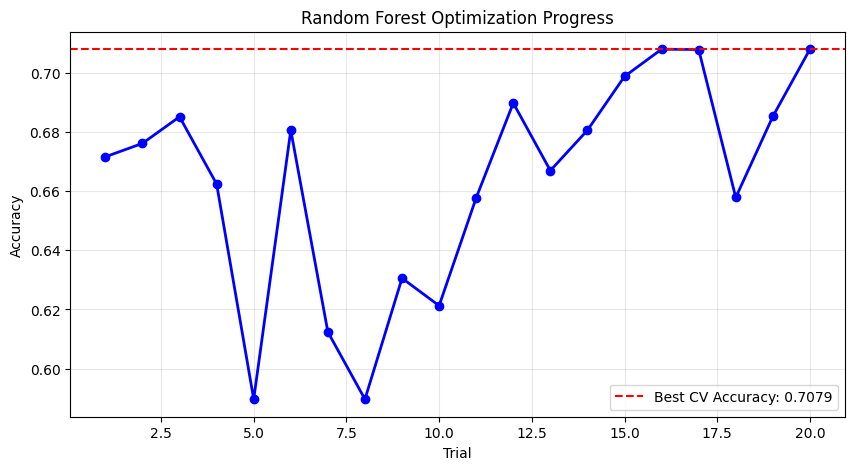

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=52)
train_accuracies_bazov = []

def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 100)
    max_depth = trial.suggest_int('max_depth', 3, 8)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=52,
        n_jobs=-1
    )
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    mean_cv_accuracy = cv_scores.mean()
    train_accuracies_bazov.append(mean_cv_accuracy)
    return mean_cv_accuracy

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=20)

best_model = RandomForestClassifier(
    **study_rf.best_params,
    random_state=52,
    n_jobs=-1
)
best_model.fit(X_train, y_train)
test_accuracy_bazov = best_model.score(X_test, y_test)
print(f"Random Forest Test Accuracy: {test_accuracy_bazov:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_accuracies_bazov) + 1), train_accuracies_bazov, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Random Forest Optimization Progress')
plt.grid(True, alpha=0.3)
best_accuracy_bazov = max(train_accuracies_bazov)
plt.axhline(y=best_accuracy_bazov, color='r', linestyle='--', label=f'Best CV Accuracy: {best_accuracy_bazov:.4f}')
plt.legend()
plt.show()

In [ ]:
X_stat = X.copy()
X_stat = X_stat.drop(['meta_mean','meta_skew'], axis = 1)

[I 2025-11-07 23:47:44,567] A new study created in memory with name: no-name-8225f659-53f7-4b7c-a118-5cf0920dc3a8
[I 2025-11-07 23:47:46,170] Trial 0 finished with value: 0.7488372093023256 and parameters: {'n_estimators': 102, 'max_depth': 10, 'min_samples_split': 2}. Best is trial 0 with value: 0.7488372093023256.
[I 2025-11-07 23:47:47,395] Trial 1 finished with value: 0.7446088794926005 and parameters: {'n_estimators': 120, 'max_depth': 8, 'min_samples_split': 2}. Best is trial 0 with value: 0.7488372093023256.
[I 2025-11-07 23:47:48,711] Trial 2 finished with value: 0.7307610993657506 and parameters: {'n_estimators': 122, 'max_depth': 10, 'min_samples_split': 4}. Best is trial 0 with value: 0.7488372093023256.
[I 2025-11-07 23:47:49,950] Trial 3 finished with value: 0.7535940803382664 and parameters: {'n_estimators': 124, 'max_depth': 7, 'min_samples_split': 3}. Best is trial 3 with value: 0.7535940803382664.
[I 2025-11-07 23:47:51,600] Trial 4 finished with value: 0.7443974630021

Random Forest Test Accuracy: 0.7455


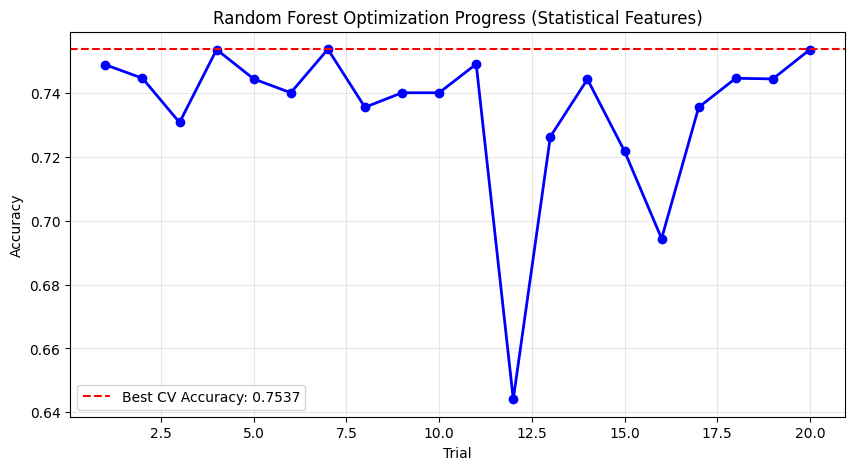

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_stat, y, test_size=0.2, random_state=52)
train_accuracies = []

def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=52,
        n_jobs=-1
    )
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    mean_cv_accuracy = cv_scores.mean()
    train_accuracies.append(mean_cv_accuracy)
    return mean_cv_accuracy

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=20)

best_model = RandomForestClassifier(
    **study_rf.best_params,
    random_state=52,
    n_jobs=-1
)
best_model.fit(X_train, y_train)
test_accuracy = best_model.score(X_test, y_test)
print(f"Random Forest Test Accuracy: {test_accuracy:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Random Forest Optimization Progress (Statistical Features)')
plt.grid(True, alpha=0.3)
best_accuracy = max(train_accuracies)
plt.axhline(y=best_accuracy, color='r', linestyle='--', label=f'Best CV Accuracy: {best_accuracy:.4f}')
plt.legend()
plt.show()

In [ ]:
X_struc = X.copy()
X_struc = X_struc.drop(['n_estimators','max_depth','min_samples_split'],axis = 1)

[I 2025-11-07 23:49:01,122] A new study created in memory with name: no-name-6fff345f-5789-490f-8d55-7bef2a4c4b24
[I 2025-11-07 23:49:02,793] Trial 0 finished with value: 0.7534883720930232 and parameters: {'n_estimators': 172, 'max_depth': 14, 'min_samples_split': 2}. Best is trial 0 with value: 0.7534883720930232.
[I 2025-11-07 23:49:04,077] Trial 1 finished with value: 0.7626849894291754 and parameters: {'n_estimators': 126, 'max_depth': 12, 'min_samples_split': 4}. Best is trial 1 with value: 0.7626849894291754.
[I 2025-11-07 23:49:05,804] Trial 2 finished with value: 0.7535940803382665 and parameters: {'n_estimators': 182, 'max_depth': 14, 'min_samples_split': 7}. Best is trial 1 with value: 0.7626849894291754.
[I 2025-11-07 23:49:06,922] Trial 3 finished with value: 0.7490486257928117 and parameters: {'n_estimators': 113, 'max_depth': 8, 'min_samples_split': 9}. Best is trial 1 with value: 0.7626849894291754.
[I 2025-11-07 23:49:08,963] Trial 4 finished with value: 0.758139534883

Random Forest Test Accuracy (Structural): 0.7818


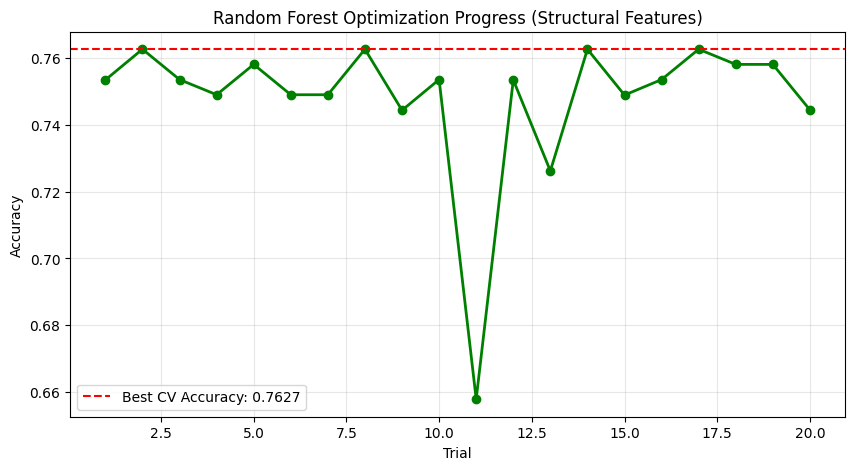

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_struc, y, test_size=0.2, random_state=52)
train_accuracies_struc = []

def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=52,
        n_jobs=-1
    )
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    mean_cv_accuracy = cv_scores.mean()
    train_accuracies_struc.append(mean_cv_accuracy)
    return mean_cv_accuracy

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=20)

best_model = RandomForestClassifier(
    **study_rf.best_params,
    random_state=52,
    n_jobs=-1
)
best_model.fit(X_train, y_train)
test_accuracy_struc = best_model.score(X_test, y_test)
print(f"Random Forest Test Accuracy (Structural): {test_accuracy_struc:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_accuracies_struc) + 1), train_accuracies_struc, 'go-', linewidth=2, markersize=6)
plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Random Forest Optimization Progress (Structural Features)')
plt.grid(True, alpha=0.3)
best_accuracy_struc = max(train_accuracies_struc)
plt.axhline(y=best_accuracy_struc, color='r', linestyle='--', label=f'Best CV Accuracy: {best_accuracy_struc:.4f}')
plt.legend()
plt.show()

In [ ]:
dataset = openml.datasets.get_dataset(54)
X_full, y_full, _, _ = dataset.get_data(target=dataset.default_target_attribute, dataset_format='dataframe')
dataset_df = X_full.copy()
dataset_df['target'] = y_full
X_orig = X_full.copy()
y_orig = y_full.copy()
y_modified = np.random.permutation(y_orig)
X_modified = X_orig.copy()
for col in X_modified.columns:
  X_modified.loc[X_modified.index[:100], col] = np.random.uniform(0, 100, 100)

In [ ]:
meta_features_modified = calculate_meta_features(X_modified, y_modified)
index = 2
modified_meta_dataset = large_meta_dataset.copy()
meta_columns = ['n_features', 'n_samples', 'n_classes', 'samples_features_ratio', 'meta_min', 'meta_max', 'meta_mean', 'meta_std', 'meta_skew', 'meta_kurtosis', 'categorical_count', 'numerical_count']
for i, col in enumerate(meta_columns):
    if i < len(meta_features_modified):
        modified_meta_dataset.at[vehicle_index, col] = meta_features_modified[i]
algorithms_scores_modified = []
rf_params_modified = {}
for algo_id in range(3):
    score, params = evaluate_algorithm(X_modified, y_modified, algo_id)
    if algo_id == 0:
        rf_params_modified = params
    algorithms_scores_modified.append(score)
best_algorithm_modified = np.argmax(algorithms_scores_modified)
modified_meta_dataset.at[index, 'best_algorithm'] = best_algorithm_modified
modified_meta_dataset.at[index, 'n_estimators'] = rf_params_modified.get('n_estimators', 100)
modified_meta_dataset.at[index, 'max_depth'] = rf_params_modified.get('max_depth', 10)
modified_meta_dataset.at[index, 'min_samples_split'] = 1 if rf_params_modified.get('min_samples_split', True) else 0

[I 2025-11-07 23:50:19,450] A new study created in memory with name: no-name-ecb940bd-4260-4078-8b85-817f02da6e73
[I 2025-11-07 23:50:19,819] Trial 1 finished with value: 0.26713947990543735 and parameters: {'n_estimators': 21, 'max_depth': 5, 'min_samples_split': 5}. Best is trial 1 with value: 0.26713947990543735.
[I 2025-11-07 23:50:19,979] Trial 0 finished with value: 0.26832151300236406 and parameters: {'n_estimators': 39, 'max_depth': 4, 'min_samples_split': 6}. Best is trial 0 with value: 0.26832151300236406.
[I 2025-11-07 23:50:19,983] A new study created in memory with name: no-name-6eafc513-5637-4b39-a045-683ae92fa169
[I 2025-11-07 23:50:20,341] Trial 1 finished with value: 0.24940898345153661 and parameters: {'n_estimators': 51, 'max_depth': 7, 'min_samples_split': 9}. Best is trial 1 with value: 0.24940898345153661.
[I 2025-11-07 23:50:20,706] Trial 0 finished with value: 0.2576832151300237 and parameters: {'n_estimators': 63, 'max_depth': 8, 'min_samples_split': 7}. Best i

In [ ]:
modified_cleaned_meta_dataset = modified_meta_dataset.drop(columns=['meta_std', 'meta_min', 'meta_max'])
X_meta = modified_cleaned_meta_dataset.drop(columns=['best_algorithm'])
y_meta = modified_cleaned_meta_dataset['best_algorithm']
X_train_mod, X_test_mod, y_train_mod, y_test_mod = train_test_split(X_meta, y_meta, test_size=0.2, random_state=52)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=20)
best_model = RandomForestClassifier(**study_rf.best_params, random_state=52)
best_model.fit(X_train_mod, y_train_mod)
test_accuracy = best_model.score(X_test_mod, y_test_mod)
print(f"Accuracy: {test_accuracy:.2f}")

[I 2025-11-07 23:50:33,235] A new study created in memory with name: no-name-cd922c0e-9175-47dd-b66c-47d4eb22ec95
[I 2025-11-07 23:50:34,810] Trial 0 finished with value: 0.7626849894291754 and parameters: {'n_estimators': 124, 'max_depth': 7, 'min_samples_split': 10}. Best is trial 0 with value: 0.7626849894291754.
[I 2025-11-07 23:50:35,995] Trial 1 finished with value: 0.7534883720930232 and parameters: {'n_estimators': 117, 'max_depth': 9, 'min_samples_split': 3}. Best is trial 0 with value: 0.7626849894291754.
[I 2025-11-07 23:50:37,559] Trial 2 finished with value: 0.7534883720930232 and parameters: {'n_estimators': 160, 'max_depth': 9, 'min_samples_split': 3}. Best is trial 0 with value: 0.7626849894291754.
[I 2025-11-07 23:50:38,151] Trial 3 finished with value: 0.7534883720930232 and parameters: {'n_estimators': 56, 'max_depth': 8, 'min_samples_split': 4}. Best is trial 0 with value: 0.7626849894291754.
[I 2025-11-07 23:50:39,423] Trial 4 finished with value: 0.762684989429175

Accuracy: 0.75
